<a href="https://colab.research.google.com/github/meteoromuri/AtlasCaio/blob/master/Copy_of_Tutorial_fortran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Note que no colab voce deve apertar shist +enter ou apertar no simbolo 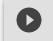 para rodar um bloco
A linha abaixo escreve com o comando %ffile o programa hellofortran.f90


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### O Grads é instalado para verificar a estrutura de dados

In [ ]:
!apt install grads
!pip install cartopy
!pip install shapely

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libdap27 libdapclient6v5 libgrib2c0d libshp2
The following NEW packages will be installed:
  grads libdap27 libdapclient6v5 libgrib2c0d libshp2
0 upgraded, 5 newly installed, 0 to remove and 2 not upgraded.
Need to get 5,236 kB of archives.
After this operation, 13.3 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libdap27 amd64 3.20.9-1 [490 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 libshp2 amd64 1.5.0-3~jammy0 [39.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libdapclient6v5 amd64 3.20.9-1 [87.4 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgrib2c0d amd64 1.6.3-1 [48.7 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 grads amd64 3:2.2.1-4build1 [4,570 kB]
Fetched 5,236 kB in 2s (2,454 kB/

In [ ]:
# Criar um link simbólico para o executável 'grads' em /usr/local/bin
!ln -s /usr/bin/grads /usr/local/bin/grads

### Entendendo o Programa `hellofortran.f90`

Este é um programa `Fortran` muito simples que demonstra os conceitos básicos de um programa e sua execução.

#### Código `hellofortran.f90`:

```fortran
! programa  hellofortran.f
! exclamação em fortran =comentario
program hello
print *, "Hello World!"
end program
```

*   `! programa hellofortran.f` e `! exclamação em fortran =comentario`: Linhas que começam com `!` em Fortran são comentários. Elas são ignoradas pelo compilador e servem para documentar o código.
*   `program hello`: Define o início de um programa Fortran e lhe dá o nome `hello`.
*   `print *, "Hello World!"`: Esta é a instrução principal. Ela imprime a string "Hello World!" na saída padrão (geralmente o console ou terminal).
*   `end program`: Indica o fim do programa `hello`.

#### Compilação e Execução no Colab:

1.  **Criação do arquivo (`%%file hellofortran.f90`)**:
    O comando mágico `%%file hellofortran.f90` é usado no Colab para criar um arquivo chamado `hellofortran.f90` no sistema de arquivos da máquina virtual, com o conteúdo fornecido.

2.  **Visualização do conteúdo (`!cat hellofortran.f990`)**:
    O comando `!cat hellofortran.f90` (onde `!` executa um comando shell) é usado para exibir o conteúdo do arquivo que acabamos de criar, confirmando que ele foi escrito corretamente.

3.  **Compilação (`!gfortran -o hellofortran hellofortran.f90`)**:
    *   `!gfortran`: Invoca o compilador GNU Fortran.
    *   `-o hellofortran`: Especifica que o arquivo de saída (executável) deve ser nomeado `hellofortran`.
    *   `hellofortran.f90`: É o arquivo de código fonte Fortran a ser compilado.
    Após a execução deste comando, um arquivo executável chamado `hellofortran` é criado.

4.  **Execução (`!./hellofortran`)**:
    *   `!./hellofortran`: O `.` indica que o executável está no diretório atual, e `hellofortran` é o nome do programa compilado. Este comando executa o programa, que por sua vez imprime "Hello World!" no console.

In [ ]:
%%file hellofortran.f90
! programa  hellofortran.f
! exclamação em fortran =comentario
program hello
print *, "Hello World!"
end program

Writing hellofortran.f90


exclamação ! em no colab (jupyter notebook) chama uma linha de comando


In [ ]:
!cat  hellofortran.f90

! programa  hellofortran.f
! exclamação em fortran =comentario
program hello
print *, "Hello World!"
end program


O comando abaixo compila o programa hellofortran.f90

In [ ]:
!gfortran  -o  hellofortran hellofortran.f90

O comando abaixo executa o programa hellofortran


In [ ]:
!./hellofortran

 Hello World!


! código para preencher x com numeros entre -49 e 50
com 10 X 10 pontos lat lon conforme o ctl abaixo

### Entendendo o Programa `fortran_write.f90`

Este programa Fortran foi criado para gerar uma matriz de valores que simulam uma distribuição Gaussiana (em forma de sino) em uma grade 2D. Ele então escreve esses valores em um arquivo binário (`out.r4`) e os exibe na tela.

#### Código `fortran_write.f90`:

```fortran
program fortran_write

  implicit none

  integer, parameter :: nx = 40, ny = 40 ! dimensoes do mapa
  real, parameter :: max_value =10.0, decay_radius = 1.0 ! parametros da gaussiana

  real :: x, y, dx, dy, value(nx,ny)
  integer :: i, j

  dx = 1.0 / real(nx-1) ! espacamento dos pontos na direcao x
  dy = 1.0 / real(ny-1) ! espacamento dos pontos na direcao y

  ! loop sobre todos os pontos do mapa
  do j = 1, ny
    do i = 1, nx

      ! calcula a distancia do ponto atual ao centro do mapa
      x = (i-1) * dx - 0.5
      y = (j-1) * dy - 0.5
      value(i,j) = max_value * exp(-((x**2 + y**2)/decay_radius**2))

    end do
  end do
  open (unit=1,file='out.r4',form='unformatted',access='direct',recl=nx*ny*4)
  ! escreve o arquivo binario
  write(1,rec=1) value
  ! imprime o mapa na tela
  do j = 1, ny
    do i = 1, nx
      write(*,'(F5.1)',advance='no') value(i,j)
    end do
    write(*,*)
  end do

end program fortran_write
```

#### Explicação Detalhada:

1.  **`program fortran_write`**: Declara o início do programa.

2.  **`implicit none`**: Uma boa prática em Fortran que exige a declaração explícita de todas as variáveis, ajudando a evitar erros de digitação e lógica.

3.  **Parâmetros de Configuração**:
    *   `nx = 40, ny = 40`: Definem as dimensões da grade (40 pontos em X e 40 pontos em Y).
    *   `max_value = 10.0`: O valor máximo da distribuição Gaussiana (no centro).
    *   `decay_radius = 1.0`: Controla a 'largura' ou o quão rapidamente os valores decaem do centro.

4.  **Declaração de Variáveis**: `x`, `y`, `dx`, `dy` são variáveis reais, e `value(nx,ny)` é uma matriz 2D para armazenar os valores calculados. `i`, `j` são contadores de loop.

5.  **Cálculo dos Espaçamentos (`dx`, `dy`)**:
    *   `dx = 1.0 / real(nx-1)` e `dy = 1.0 / real(ny-1)`: Calculam o espaçamento entre os pontos na grade para normalizar as coordenadas `x` e `y` em um intervalo de 0 a 1 (ou -0.5 a 0.5 quando centralizado).

6.  **Loop para Gerar Valores Gaussiano**:
    *   `do j = 1, ny` e `do i = 1, nx`: Loops aninhados percorrem cada ponto da grade.
    *   `x = (i-1) * dx - 0.5` e `y = (j-1) * dy - 0.5`: Transformam os índices `i` e `j` em coordenadas `x` e `y` que variam de -0.5 a 0.5, centralizando a distribuição no ponto (0,0).
    *   `value(i,j) = max_value * exp(-((x**2 + y**2)/decay_radius**2))`: Esta é a fórmula para uma função Gaussiana 2D. O termo `x**2 + y**2` representa a distância quadrada do centro. À medida que a distância do centro aumenta, o expoente se torna mais negativo, fazendo com que `exp()` diminua e o valor `value(i,j)` se aproxime de zero.

7.  **Escrita para Arquivo Binário (`out.r4`)**:
    *   `open (unit=1,file='out.r4',form='unformatted',access='direct',recl=nx*ny*4)`:
        *   `unit=1`: Associa o arquivo a um número de unidade interna para referência.
        *   `file='out.r4'`: Define o nome do arquivo de saída.
        *   `form='unformatted'`: Indica que o arquivo será um arquivo binário (sem formatação de texto).
        *   `access='direct'`: Permite o acesso direto a registros específicos no arquivo (embora aqui usemos apenas um registro).
        *   `recl=nx*ny*4`: Define o tamanho do registro em bytes. Como `nx` e `ny` são 40, e cada `real` (ponto flutuante de precisão simples) ocupa 4 bytes, o tamanho total do registro é `40 * 40 * 4 = 6400` bytes. Isso é crucial para que o GrADS (ou qualquer outro programa) saiba quantos bytes ler para cada matriz completa.
    *   `write(1,rec=1) value`: Escreve toda a matriz `value` como um único registro no arquivo `out.r4`.

8.  **Impressão na Tela**:
    *   Os loops aninhados `do j = 1, ny` e `do i = 1, nx` percorrem novamente a matriz.
    *   `write(*,'(F5.1)',advance='no') value(i,j)`: Imprime cada valor formatado com 5 caracteres totais e 1 casa decimal. `advance='no'` impede que o cursor pule para a próxima linha após cada valor, permitindo que eles sejam impressos lado a lado.
    *   `write(*,*)`: Após cada linha da matriz ser impressa, um `write` vazio avança para a próxima linha, formatando a saída para parecer uma matriz 2D.

9.  **`end program fortran_write`**: Finaliza o programa.

Este programa é um exemplo prático de como gerar dados científicos em Fortran, salvá-los em um formato binário bruto e visualizá-los, o que é uma etapa comum antes de usar ferramentas como o GrADS para análise mais aprofundada.

In [1]:
%%file fortran_write.f90
program fortran_write

  implicit none

  integer, parameter :: nx = 40, ny = 40 ! dimensoes do mapa
  real, parameter :: max_value =10.0, decay_radius = 1.0 ! parametros da gaussiana

  real :: x, y, dx, dy, value(nx,ny)
  integer :: i, j

  dx = 1.0 / real(nx-1) ! espacamento dos pontos na direcao x
  dy = 1.0 / real(ny-1) ! espacamento dos pontos na direcao y

  ! loop sobre todos os pontos do mapa
  do j = 1, ny
    do i = 1, nx

      ! calcula a distancia do ponto atual ao centro do mapa
      x = (i-1) * dx - 0.5
      y = (j-1) * dy - 0.5
      value(i,j) = max_value * exp(-((x**2 + y**2)/decay_radius**2))

    end do
  end do
  open (unit=1,file='out.r4',form='unformatted',access='direct',recl=nx*ny*4)
  ! escreve o arquivo binario
  write(1,rec=1) value
  close(1)
  ! imprime o mapa na tela
  do j = 1, ny
    do i = 1, nx
      write(*,'(F5.1)',advance='no') value(i,j)
    end do
    write(*,*)
  end do

end program fortran_write


Writing fortran_write.f90


In [2]:
!gfortran -fconvert=big-endian  -o fortran_write.exe  fortran_write.f90

In [3]:
!./fortran_write.exe

  6.1  6.2  6.4  6.5  6.7  6.8  6.9  7.0  7.1  7.2  7.3  7.4  7.5  7.6  7.6  7.7  7.7  7.8  7.8  7.8  7.8  7.8  7.8  7.7  7.7  7.6  7.6  7.5  7.4  7.3  7.2  7.1  7.0  6.9  6.8  6.7  6.5  6.4  6.2  6.1
  6.2  6.4  6.5  6.7  6.8  7.0  7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.8  7.9  7.9  8.0  8.0  8.0  8.0  8.0  8.0  7.9  7.9  7.8  7.8  7.7  7.6  7.5  7.4  7.3  7.2  7.1  7.0  6.8  6.7  6.5  6.4  6.2
  6.4  6.5  6.7  6.8  7.0  7.1  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.0  8.0  8.1  8.1  8.1  8.2  8.2  8.2  8.2  8.1  8.1  8.1  8.0  8.0  7.9  7.8  7.7  7.6  7.5  7.4  7.3  7.1  7.0  6.8  6.7  6.5  6.4
  6.5  6.7  6.8  7.0  7.1  7.3  7.4  7.5  7.7  7.8  7.9  8.0  8.1  8.1  8.2  8.3  8.3  8.3  8.3  8.4  8.4  8.3  8.3  8.3  8.3  8.2  8.1  8.1  8.0  7.9  7.8  7.7  7.5  7.4  7.3  7.1  7.0  6.8  6.7  6.5
  6.7  6.8  7.0  7.1  7.3  7.4  7.6  7.7  7.8  7.9  8.0  8.1  8.2  8.3  8.4  8.4  8.5  8.5  8.5  8.5  8.5  8.5  8.5  8.5  8.4  8.4  8.3  8.2  8.1  8.0  7.9  7.8  7.7  7.6  7.4  7.3  7.1  7.0  6.8 

In [4]:
!ls -l

total 36
-rwxr-xr-x 1 root root 16480 Apr 18 23:40 fortran_write.exe
-rw-r--r-- 1 root root   954 Apr 18 23:39 fortran_write.f90
-rw-r--r-- 1 root root  6400 Apr 18 23:40 out.r4
drwxr-xr-x 1 root root  4096 Apr 16 13:28 sample_data


## ! código para ler x com numeros entre -49 e 50


## com 40 X 40 pontos lat lon conforme o ctl abaixo

In [5]:
%%file fortran_read.f90
program fortran_read
implicit none

  integer, parameter :: nx = 40, ny = 40 ! dimensoes do mapa
  real, parameter :: max_value =10.0, decay_radius = 1.0 ! parametros da gaussiana

  real :: x, y, dx, dy, value(nx,ny)
  integer :: i, j

  open (unit=1,file='out.r4',form='unformatted',access='direct',recl=nx*ny*4)

  ! Leia a matrix x como um arquivo binario m*n*4 bytes

  read(1,rec=1) value

do j = 1, ny
  do i = 1, nx
      write(*,'(F5.1)',advance='no') value(i,j)
    end do
    write(*,*)
  end do


end program fortran_read



Writing fortran_read.f90


In [6]:
!gfortran -fconvert=big-endian  -o fortran_read.exe  fortran_read.f90

In [7]:
!./fortran_read.exe

  6.1  6.2  6.4  6.5  6.7  6.8  6.9  7.0  7.1  7.2  7.3  7.4  7.5  7.6  7.6  7.7  7.7  7.8  7.8  7.8  7.8  7.8  7.8  7.7  7.7  7.6  7.6  7.5  7.4  7.3  7.2  7.1  7.0  6.9  6.8  6.7  6.5  6.4  6.2  6.1
  6.2  6.4  6.5  6.7  6.8  7.0  7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.8  7.9  7.9  8.0  8.0  8.0  8.0  8.0  8.0  7.9  7.9  7.8  7.8  7.7  7.6  7.5  7.4  7.3  7.2  7.1  7.0  6.8  6.7  6.5  6.4  6.2
  6.4  6.5  6.7  6.8  7.0  7.1  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.0  8.0  8.1  8.1  8.1  8.2  8.2  8.2  8.2  8.1  8.1  8.1  8.0  8.0  7.9  7.8  7.7  7.6  7.5  7.4  7.3  7.1  7.0  6.8  6.7  6.5  6.4
  6.5  6.7  6.8  7.0  7.1  7.3  7.4  7.5  7.7  7.8  7.9  8.0  8.1  8.1  8.2  8.3  8.3  8.3  8.3  8.4  8.4  8.3  8.3  8.3  8.3  8.2  8.1  8.1  8.0  7.9  7.8  7.7  7.5  7.4  7.3  7.1  7.0  6.8  6.7  6.5
  6.7  6.8  7.0  7.1  7.3  7.4  7.6  7.7  7.8  7.9  8.0  8.1  8.2  8.3  8.4  8.4  8.5  8.5  8.5  8.5  8.5  8.5  8.5  8.5  8.4  8.4  8.3  8.2  8.1  8.0  7.9  7.8  7.7  7.6  7.4  7.3  7.1  7.0  6.8 

### GrADS (Grid Analysis and Display System) e Arquivos .ctl

O GrADS é uma ferramenta interativa e poderosa para o acesso, manipulação e visualização de dados geoespaciais, especialmente dados meteorológicos e oceanográficos. Ele é amplamente utilizado na pesquisa e operação de modelos climáticos e atmosféricos.

Uma característica fundamental do GrADS é a forma como ele lida com os dados: ele geralmente não trabalha diretamente com os arquivos binários brutos, mas sim com um arquivo de controle (com extensão `.ctl`) que descreve a estrutura desses dados binários. O arquivo `.ctl` funciona como um metadado, informando ao GrADS como interpretar o arquivo binário correspondente.

#### O que contém um arquivo .ctl?

O arquivo `.ctl` contém informações cruciais como:

*   **`DSET`**: Caminho para o arquivo de dados binário associado (`.dat`, `.r4`, `.bin`, etc.).
*   **`OPTIONS`**: Opções de leitura, como `yrev` (para inverter a ordem do eixo Y), `big_endian` ou `little_endian` (para especificar a ordem dos bytes do arquivo binário), `sequential`, etc.
*   **`TITLE`**: Um título descritivo para o conjunto de dados.
*   **`UNDEF`**: O valor usado para representar dados indefinidos ou ausentes (missing values).
*   **`XDEF`, `YDEF`, `ZDEF`, `TDEF`**: Definições das dimensões (longitude, latitude, nível vertical, tempo) dos dados. Isso inclui o número de pontos, o tipo de projeção (linear, gaulesa, etc.), os valores inicial e de espaçamento, ou uma lista de níveis/tempos específicos.
*   **`VARS`**: Uma lista das variáveis contidas no arquivo binário, incluindo o número de níveis, uma descrição e, opcionalmente, um fator de escala ou offset.
*   **`ENDVARS`**: Marca o fim da seção de variáveis.

#### Importância do .ctl para o GrADS

Sem o arquivo `.ctl`, o GrADS não conseguiria saber como organizar e interpretar os fluxos de bytes dentro de um arquivo binário. Por exemplo, ele não saberia quais bytes representam a longitude, quais representam a latitude, qual o tipo de dado (inteiro, real), se os dados estão em 32 ou 64 bits, ou mesmo se estão em ordem `big-endian` ou `little-endian`.

É por isso que, ao trabalhar com dados binários no GrADS, a correta criação e configuração do arquivo `.ctl` é tão fundamental quanto a geração do próprio arquivo binário. Um erro na especificação da ordem de bytes (endianness), por exemplo, pode fazer com que o GrADS leia os dados de forma completamente incorreta, resultando em valores sem sentido ou até mesmo em erros de leitura.

### GrADS, Arquivos .ctl e a Ordem de Bytes (Endianness)

Entender a relação entre os arquivos `.ctl` do GrADS, a ordem de bytes (endianness) e os diversos formatos de dados é crucial para manipular corretamente informações geoespaciais e meteorológicas.

#### O Papel do `.ctl` com Diferentes Formatos de Dados

O GrADS é projetado para ser flexível em sua capacidade de acessar dados. Enquanto o formato de arquivo binário "plano" (como `.r4`, `.bin`, `.dat`) é um dos mais comuns para uso com `.ctl`, o GrADS também pode interagir com outros formatos, desde que tenha os drivers ou bibliotecas apropriadas. No entanto, o `.ctl` se torna estritamente necessário e detalhado quando se trabalha com *arquivos binários planos*, pois são eles que não contêm metadados internos para descrever sua estrutura. Formatos como:

*   **NetCDF (Network Common Data Form)**: É um formato de arquivo autodescritivo e multi-plataforma para dados científicos. Arquivos NetCDF já contêm todas as informações de metadados (dimensões, variáveis, atributos, tipo de dado, endianness, etc.) em seu cabeçalho. O GrADS pode ler NetCDF diretamente, muitas vezes sem a necessidade de um `.ctl` explícito, pois ele pode extrair as informações necessárias do próprio arquivo NetCDF.
*   **HDF (Hierarchical Data Format)**: Semelhante ao NetCDF, o HDF (HDF4 e HDF5) é um formato de arquivo de dados complexo e autodescritivo. O GrADS pode ter suporte limitado ou exigir a conversão para formatos mais simples ou o uso de ferramentas externas para extrair dados antes de serem lidos pelo GrADS, ou em alguns casos, pode usar `.ctl`s com opções específicas para HDF.
*   **GRIB (GRIdded Binary)**: Um formato amplamente usado em meteorologia para dados de modelos numéricos. O GrADS tem suporte nativo para GRIB e GRIB2 e não requer um arquivo `.ctl` para lê-los, pois as informações de grade e variáveis estão codificadas no próprio arquivo GRIB.

Para esses formatos autodescritivos, o `.ctl` do GrADS age mais como um "atalho" ou uma forma de pré-configurar o acesso, mas a informação fundamental está no arquivo de dados. No entanto, para arquivos binários puros, o `.ctl` é a *única fonte* de metadados para o GrADS.

#### Endianness: Big Endian vs. Little Endian

A **endianness** refere-se à ordem em que bytes de dados de múltiplas unidades (como inteiros de 4 bytes ou números de ponto flutuante de 4 ou 8 bytes) são armazenados na memória de um computador. Existem duas ordens principais:

*   **Big Endian**: O byte mais significativo (o byte mais à esquerda, como na escrita normal) é armazenado primeiro no endereço de memória mais baixo. É como lemos números da esquerda para a direita. Exemplos clássicos incluem a arquitetura Motorola 68k e o formato de rede padrão TCP/IP.
*   **Little Endian**: O byte menos significativo (o byte mais à direita) é armazenado primeiro no endereço de memória mais baixo. A maioria dos processadores Intel x86 e x64 usa little-endian.

#### A Importância da Endianness em Arquivos `.ctl`

Quando você está trabalhando com *arquivos binários planos* (por exemplo, `.r4` ou `.bin`) que não são autodescritivos, a endianness é uma das informações mais críticas que o arquivo `.ctl` deve fornecer ao GrADS. Se o `.ctl` especificar a endianness incorreta para o arquivo binário:

1.  **Leitura Incorreta**: O GrADS interpretará os bytes na ordem errada, resultando em valores numéricos completamente distorcidos. Por exemplo, um número de ponto flutuante que deveria ser `3.14` pode ser lido como um valor aleatório muito grande ou muito pequeno, ou até mesmo um "Not a Number" (NaN).
2.  **Erros na Visualização**: Mapas e gráficos gerados a partir desses dados estarão errados, mostrando padrões sem sentido ou ruído.

No arquivo `.ctl`, a opção `OPTIONS` é usada para especificar a endianness:

*   `OPTIONS big_endian`: Indica que o arquivo binário foi escrito em ordem big-endian.
*   `OPTIONS little_endian`: Indica que o arquivo binário foi escrito em ordem little-endian.

Para arquivos binários gerados por programas Fortran, a opção de compilação `-fconvert=big-endian` ou `-fconvert=little-endian` (ou similar, dependendo do compilador) controla como os dados são escritos no disco. É fundamental que a opção `convert` no comando `open` do Fortran (se for usada) e a `OPTIONS` no `.ctl` do GrADS correspondam perfeitamente à forma como os bytes foram gravados.

Em resumo, para formatos de dados como NetCDF ou HDF, a endianness é geralmente tratada internamente ou é uma convenção padrão do formato. Mas para arquivos binários puros, o `.ctl` do GrADS é o seu guia essencial para interpretar a ordem dos bytes, e um erro nessa especificação pode inviabilizar toda a análise de dados.

### Exite um erro no CTL abaixo, relacionado com o tipo de binario
### (big_endian ou liitle_endian) que impede o GrADS ler corretamente a
### variavel temp
### Você consegue corrigir?

In [22]:
%%file out.ctl
DSET ^out.r4
OPTIONS little_endian
TITLE Gridded Data Sample
UNDEF -9.99E33
XDEF 40 LINEAR -78.0 2.0
YDEF 40 LINEAR -60.0 2.0
ZDEF 1 LEVELS 1000
TDEF 1 LINEAR 0Z20jun1965 12hr
VARS 1
temp 0 99 temperature
ENDVARS

Overwriting out.ctl


In [21]:
ls -l out.r4

-rw-r--r-- 1 root root 6400 Apr 18 23:40 out.r4


In [28]:
# Para Ubuntu/Debian
!apt-get update
!apt-get install -y grads

# Para CentOS/RHEL/Fedora
!yum install -y grads

# Ou via conda (se tiver conda instalado)
!conda install -c conda-forge grads -y

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,970 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Ge

In [29]:
import os
# Prepend /usr/bin to PATH to ensure it's found by subprocess calls
os.environ['PATH'] = '/usr/bin:' + os.environ['PATH']

from py3grads import Grads
from matplotlib import pyplot as plt
ga = Grads(verbose=False)
ga('open out.ctl') # abrindo o arquivo controle
ga('q file 1') # mostrar as variáveis no arquiv

(['File 1 : Gridded Data Sample',
  '  Descriptor: out.ctl',
  '  Binary: out.r4',
  '  Type = Gridded',
  '  Xsize = 40  Ysize = 40  Zsize = 1  Tsize = 1  Esize = 1',
  '  Number of Variables = 1',
  '     temp  0  99  temperature',
  ''],
 0)

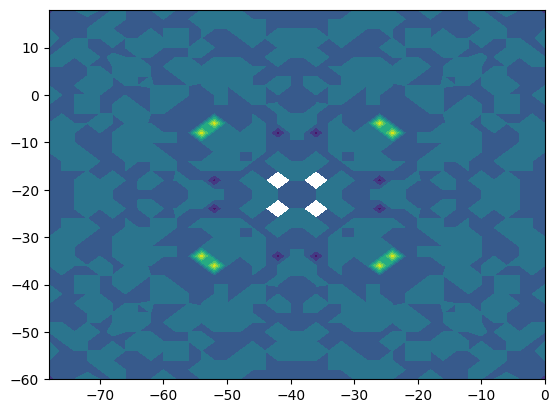

In [30]:
temp=ga.exp('temp') #pegue a variavel ps = Surface Pressure
lons = ga.exp('lon') # #pegue longitude
lats = ga.exp('lat') # #pegue latitude
[temp.min(),temp.max()] #mostre o valor menor e maior de ps
plt.contourf(lons, lats, temp)

In [31]:
dir(temp)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


In [39]:
!apt-get install cartopy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package cartopy


ModuleNotFoundError: No module named 'cartopy'

In [40]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 74.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


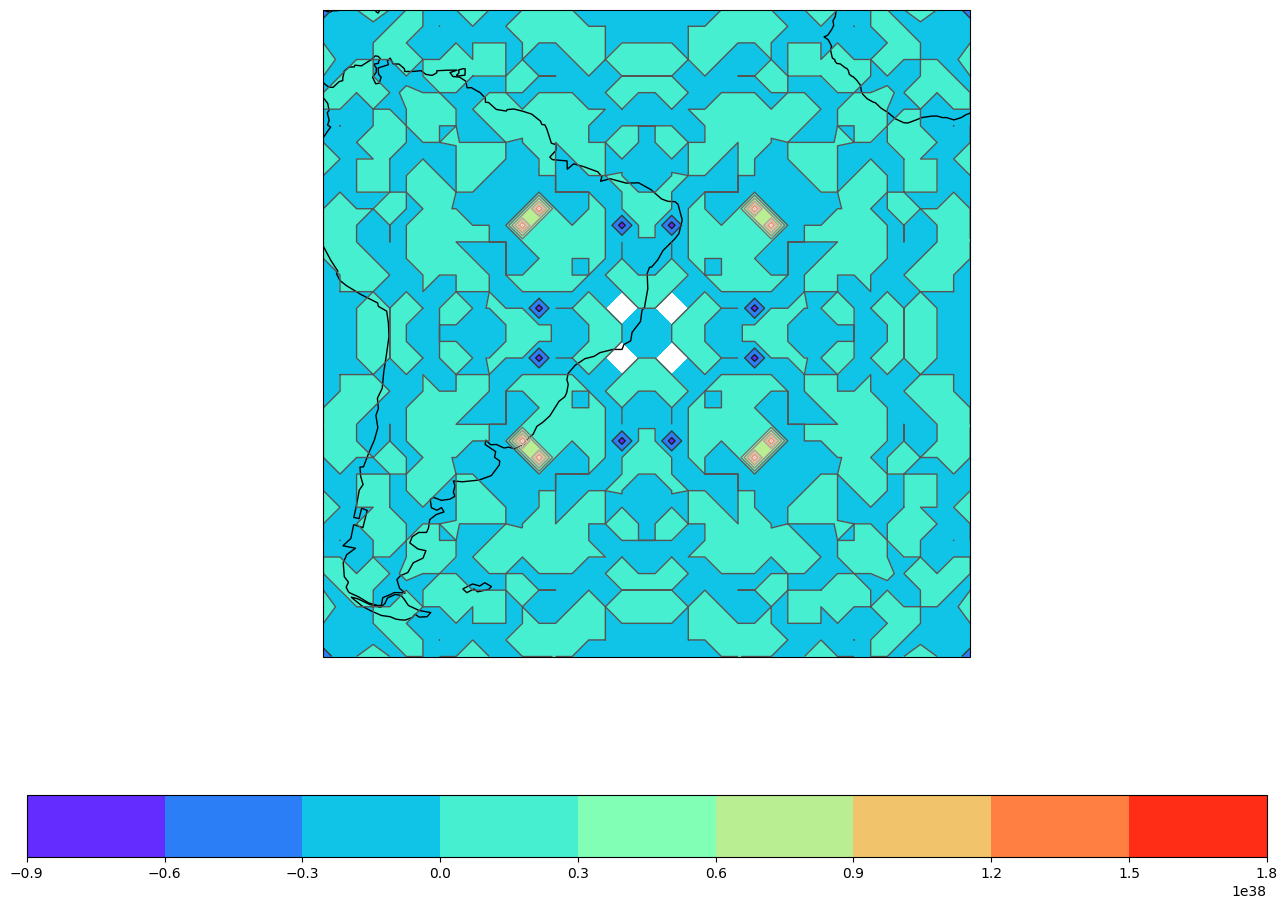

In [41]:
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
import numpy as np
plt.figure(figsize=(16,12)) # tamanho da figura
ax=plt.axes(projection=ccrs.PlateCarree()) # set a projeção
# plota em contornos [400,..104] com base no mapa de cores 'rainbow'
c1=plt.contourf(lons, lats, temp,cmap='rainbow')
# plota sobre o mapa acima com linhas com base no mapa de cores 'gray' para destacar
c2=plt.contour(lons, lats, temp,cmap='gray',linewidths=1)
#plot o mapa das linhas de costa.
ax.coastlines(color='k')
# plota a barra de cores
plt.colorbar(c1,orientation='horizontal')
#salva em arquivo

## Use os ultimos dois programas em fortran e faça um programa para ler o arquivo precip.dat abaixo e escrever em binario precip.bin (no formato big_endian)
## Faço o arquivo  precip.ctl
## O arquivo tem uma matrix (29x22) regular lat_lon com 0.5x0.5 graus de resolução e possui a média da precipitação para a América do Sul em Janeiro 2021.

### dimensions: lat = 29 (linhas) por   lon = 22 (colunas)
###    lat = 29 ; de -58.75 até  11.25 de 0.5 graus
###    lon = 22 ; de  286.25 até  338.75 de 0.5 graus
#Use o loop impl'icito
##
## Faça um programa em GrADS para imprimir o mapa
  

In [42]:
%%file precip.dat
    3.436024 3.417016 3.374969 3.520312 3.532623 3.39273 3.270427 3.198751 3.058865 3.093569 3.026887 3.067235 3.102475 3.118762 3.027629 2.961128 2.93396 2.878362 2.821587 2.899867 2.885147 2.850597
    3.739232 3.011911 2.833664 3.10923 3.932307 3.561136 3.252693 3.199015 3.028804 3.036374 2.938923 3.022136 3.056206 3.071265 3.080819 3.103547 3.041874 2.93169 2.910151 2.861184 2.902374 3.023062
    6.311544 2.462048 1.485294 2.172707 3.223597 2.883384 2.66986 2.749008 2.825372 2.825171 2.899536 2.991689 2.877376 2.809448 4.130069 4.497659 2.986385 2.924061 2.763379 2.555616 2.696198 2.687015
    3.660367 1.483618 1.379619 2.68972 2.556244 2.185741 2.208822 2.645923 2.682769 2.832681 3.193133 2.975714 3.040691 2.921024 3.214843 2.801667 2.890804 3.167514 3.081146 2.758276 2.910659 2.647861
    2.234636 1.152328 1.131199 1.163575 2.198452 2.198869 2.270976 2.261304 2.566994 2.985002 3.454995 3.340835 3.253049 3.33767 3.35183 3.32236 3.113886 3.029637 3.032029 3.024629 3.141734 2.882339
    3.075986 1.038657 0.8156019 0.8935126 1.900399 2.009001 2.030294 2.327193 2.758904 3.173784 3.318309 3.160863 3.063357 3.097107 3.350085 3.340297 3.180459 3.265936 3.182445 3.290689 3.190675 3.117588
    2.673059 2.15343 0.4205896 0.7151209 1.581671 1.820641 1.607256 2.457923 2.863195 3.110873 2.867763 2.965394 3.437332 3.703787 3.198036 3.395846 3.597849 4.045591 3.542416 3.894182 3.432469 3.163966
    2.125471 1.340029 0.6867869 0.8548189 1.692297 2.063388 2.124084 2.349394 2.906482 3.451801 3.402022 3.53711 3.448937 3.624954 3.591743 3.56101 3.607732 3.733551 3.694788 3.619618 3.083447 3.553897
    1.039438 0.6330268 0.8431969 1.392456 2.384985 3.391641 3.469744 3.899723 3.431305 3.279742 3.502793 3.543168 3.570304 3.694835 3.73896 4.282777 4.46958 4.532965 4.539852 4.623566 4.755692 4.769765
    0.5029331 0.4158133 1.320318 2.574739 3.442145 3.846447 3.865707 3.529705 3.227038 3.297053 3.434154 3.711025 3.892641 4.11351 4.17348 4.901361 4.802521 4.681963 4.640005 4.515616 4.572726 4.42497
    0.1021495 0.09568514 1.397118 3.206768 3.806364 4.306534 4.644561 4.676252 5.117114 4.078679 3.494274 4.043734 4.431087 4.781471 5.239062 5.661129 5.177056 4.86025 4.537114 4.395089 4.228317 3.652687
    0.06039324 0.1429781 1.04239 2.924685 4.012992 4.599679 4.887611 5.058413 5.328803 5.030131 3.459035 3.961904 4.646987 5.189748 5.747027 5.721869 4.998001 4.411326 4.128587 3.884349 3.374537 2.81457
    0.06224354 0.08009502 0.9463761 2.445252 3.833925 4.941758 5.64369 6.047698 5.77641 5.769054 7.418785 3.735863 4.568022 5.082227 5.276552 5.568664 4.875137 4.247166 3.662314 3.463449 2.822661 2.251572
    0.06116522 0.07815138 0.5327482 3.698691 4.204245 4.569057 5.107608 5.459993 6.496473 6.547184 7.667229 4.275294 3.706796 3.868883 4.568467 5.20697 4.578351 3.714415 3.083608 2.48132 1.824132 1.376941
    0.04569053 0.03139884 0.3751551 3.939818 5.108557 4.27663 5.063134 5.945136 5.892324 6.390081 7.010937 8.137282 7.101507 3.53315 2.957384 3.915086 3.13998 2.41064 2.029187 1.42838 0.9800115 0.8140768
    0.02242317 0.03347318 0.6799628 2.87815 5.236764 4.351687 5.093853 5.564609 6.790329 6.722239 7.663428 7.766496 6.975719 4.546651 2.598032 2.79552 2.160472 1.615065 1.085962 0.6099976 0.4729871 0.4329793
    0.03969308 0.2395023 2.122945 3.967227 5.08134 4.92271 5.271675 6.241167 8.033018 8.170132 7.979126 7.138461 5.245192 3.919742 2.957258 1.83866 1.459472 0.9016364 0.4829797 0.3676051 0.3170813 0.2841509
    1.731474 3.479595 4.941777 9.280753 8.049117 6.35692 7.546791 7.812735 8.81687 8.003133 7.806318 5.754162 4.01227 3.080217 3.448821 1.517455 1.067129 0.5817311 0.337305 0.2987025 0.2564794 0.2079517
    5.998465 10.5042 9.059268 8.776798 8.789915 9.18796 10.11463 10.66592 9.333367 8.18227 7.738291 6.339373 4.064998 2.774915 3.552574 1.321921 0.8196573 0.4195662 0.2762167 0.2197783 0.2014344 0.1470069
    9.452103 10.09832 9.701276 9.556171 9.877026 10.54986 11.12872 11.11414 10.61911 9.089942 8.565039 7.081739 4.453985 2.668249 2.233528 2.267026 1.084921 0.6812765 0.4309104 0.2924194 0.258171 0.1731363
    8.439098 9.252752 9.750667 11.15541 11.30375 11.88687 11.89666 12.05084 11.04572 10.33762 9.845781 7.39535 4.68862 3.376507 3.032196 2.799132 2.883257 0.8772962 0.6386167 0.5267707 0.4086797 0.2233506
    9.129897 10.47904 11.46901 12.26648 11.6905 12.22812 11.70223 11.43267 10.56329 10.14856 9.916701 7.758431 6.688481 5.349389 4.708415 3.533037 2.40432 1.381201 1.250599 0.9950956 0.6556499 0.3243116
    9.529033 10.46368 11.13553 10.5268 9.504885 10.58009 9.859019 10.02734 9.533164 11.67214 12.80204 10.42369 9.595784 7.261204 4.935429 3.820293 3.450749 3.496189 3.227757 2.585987 1.972514 1.346519
    7.891457 9.466827 10.45246 8.356497 7.251146 7.140458 8.309353 10.07785 8.346564 12.10027 15.32769 12.9351 9.883213 5.805648 5.741529 6.64248 6.988656 6.605833 5.703382 4.638465 3.672916 2.553982
    5.170817 6.376552 8.217744 7.164874 4.038126 2.805957 3.718009 5.806254 6.786174 11.74952 13.99271 6.488378 6.032089 7.224471 8.534633 8.975112 9.101244 8.565846 7.753098 7.035517 6.365972 5.323411
    3.543628 2.629743 3.994536 3.996297 3.354606 1.928677 2.601022 4.394343 6.569709 10.61648 4.605689 5.257506 5.635556 6.080378 6.393994 6.305453 6.018147 5.855464 5.300403 5.013666 5.510436 4.964769
    3.747196 1.733126 1.116519 1.181206 1.532104 2.804511 4.568571 3.881035 3.547969 2.997579 1.852239 2.354496 2.519274 2.499278 2.447968 2.138594 1.61682 1.448849 1.079337 0.9314607 1.052438 1.221315
    1.848404 1.715816 0.4304186 0.3037443 0.8486195 2.335957 2.499386 0.5295058 0.5551597 0.5914192 0.7248318 0.7586688 0.7206987 0.6866884 0.6623618 0.6319888 0.5279908 0.4332498 0.3230155 0.2768458 0.2559576 0.2424095
    0.8052111 0.4819725 1.005965 1.261301 1.017836 1.761237 0.6580398 0.5217314 0.4434802 0.3428361 0.2873308 0.2651268 0.2869786 0.2989376 0.2494286 0.2387426 0.2282346 0.2446525 0.2278973 0.1930602 0.1557017 0.1625803

Writing precip.dat


In [52]:
# Verificar as primeiras linhas do arquivo
!head -20 precip.dat

# Contar quantos valores por linha
!head -5 precip.dat | awk '{print NF}'

# Ver tamanho total do arquivo
!wc -l precip.dat
!du -h precip.dat

    3.436024 3.417016 3.374969 3.520312 3.532623 3.39273 3.270427 3.198751 3.058865 3.093569 3.026887 3.067235 3.102475 3.118762 3.027629 2.961128 2.93396 2.878362 2.821587 2.899867 2.885147 2.850597
    3.739232 3.011911 2.833664 3.10923 3.932307 3.561136 3.252693 3.199015 3.028804 3.036374 2.938923 3.022136 3.056206 3.071265 3.080819 3.103547 3.041874 2.93169 2.910151 2.861184 2.902374 3.023062
    6.311544 2.462048 1.485294 2.172707 3.223597 2.883384 2.66986 2.749008 2.825372 2.825171 2.899536 2.991689 2.877376 2.809448 4.130069 4.497659 2.986385 2.924061 2.763379 2.555616 2.696198 2.687015
    3.660367 1.483618 1.379619 2.68972 2.556244 2.185741 2.208822 2.645923 2.682769 2.832681 3.193133 2.975714 3.040691 2.921024 3.214843 2.801667 2.890804 3.167514 3.081146 2.758276 2.910659 2.647861
    2.234636 1.152328 1.131199 1.163575 2.198452 2.198869 2.270976 2.261304 2.566994 2.985002 3.454995 3.340835 3.253049 3.33767 3.35183 3.32236 3.113886 3.029637 3.032029 3.024629 3.141734 2.882339

In [53]:
%%file converte_precip.f90
program converte_precip
  implicit none

  ! Dimensões da grade (baseado na análise do arquivo)
  integer, parameter :: nlon = 22   ! longitudes (colunas)
  integer, parameter :: nlat = 29   ! latitudes (linhas)

  ! Declaração das variáveis
  real :: precip(nlon, nlat)
  integer :: i, j, ios
  real :: min_val, max_val, mean_val

  print *, "Convertendo precip.dat para precip.bin (big_endian)"
  print *, "Dimensões:", nlon, "longitudes x", nlat, "latitudes"
  print *, "Total de pontos:", nlon*nlat

  ! Abrir arquivo de texto para leitura
  open(unit=10, file='precip.dat', status='old', action='read', iostat=ios)
  if (ios /= 0) then
    print *, "ERRO: Não foi possível abrir precip.dat"
    stop
  end if

  ! Ler os dados - uma linha por latitude
  do j = 1, nlat
    read(10, *, iostat=ios) (precip(i, j), i = 1, nlon)
    if (ios /= 0) then
      print *, "ERRO na leitura da linha", j
      print *, "Verifique se a linha tem", nlon, "valores"
      stop
    end if
  end do

  close(10)
  print *, "Leitura concluída com sucesso!"

  ! Calcular estatísticas
  min_val = precip(1,1)
  max_val = precip(1,1)
  mean_val = 0.0

  do j = 1, nlat
    do i = 1, nlon
      if (precip(i,j) < min_val) min_val = precip(i,j)
      if (precip(i,j) > max_val) max_val = precip(i,j)
      mean_val = mean_val + precip(i,j)
    end do
  end do
  mean_val = mean_val / (nlon * nlat)

  print *, "Estatísticas dos dados:"
  print *, "  Mínimo:", min_val
  print *, "  Máximo:", max_val
  print *, "  Média:", mean_val

  ! Escrever em formato binário big_endian (formato sequencial)
  open(unit=20, file='precip.bin', form='unformatted', &
       access='sequential', convert='big_endian', iostat=ios)

  if (ios /= 0) then
    print *, "ERRO: Não foi possível criar precip.bin"
    stop
  end if

  ! Escrever a matriz inteira
  write(20) precip
  close(20)

  print *, "SUCESSO! Arquivo precip.bin criado"
  print *, "Tamanho do arquivo:", nlon*nlat*4, "bytes"

end program converte_precip

Overwriting converte_precip.f90


In [54]:
!gfortran -o converte_precip.exe converte_precip.f90
!./converte_precip.exe

 Convertendo precip.dat para precip.bin (big_endian)
 Dimensões:          22 longitudes x          29 latitudes
 Total de pontos:         638
 Leitura concluída com sucesso!
 Estatísticas dos dados:
   Mínimo:   2.24231705E-02
   Máximo:   15.3276901    
   Média:   4.02000284    
 SUCESSO! Arquivo precip.bin criado
 Tamanho do arquivo:        2552 bytes


In [55]:
%%file precip.ctl
DSET ^precip.bin
OPTIONS big_endian
TITLE Precipitacao media - America do Sul - Janeiro 2021
UNDEF -9.99E33
XDEF 22 LINEAR 286.25 0.5
YDEF 29 LINEAR -58.75 0.5
ZDEF 1 LEVELS 1000
TDEF 1 LINEAR 15JAN2021 1dy
VARS 1
precip 0 99 Precipitacao media (mm/dia)
ENDVARS

Writing precip.ctl


Dados carregados com shape: (29, 22)
Longitudes: 286.2 a 338.8
Latitudes: -58.8 a 11.2
Precipitação - Min: 0.02, Max: 15.33


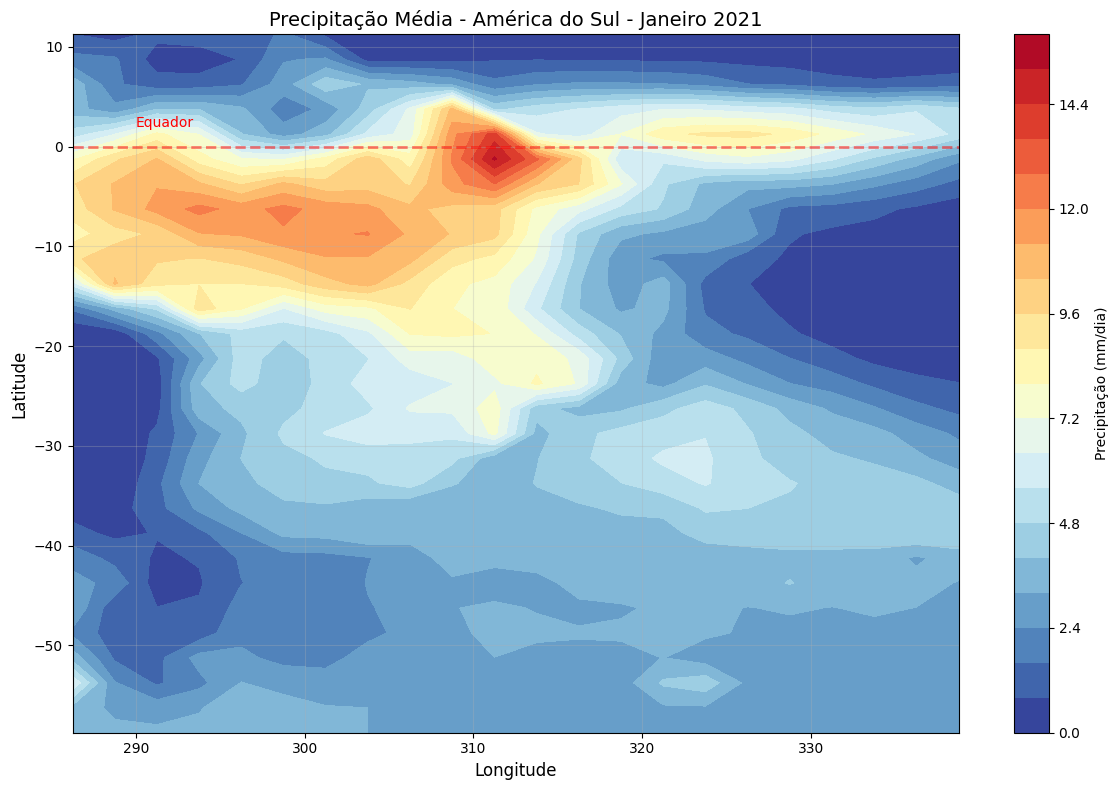

Figura salva como 'precipitacao_amsul_jan2021.png'


<Figure size 640x480 with 0 Axes>

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Ler dados diretamente do arquivo texto
data = np.loadtxt('precip.dat')
print(f"Dados carregados com shape: {data.shape}")

# Definir coordenadas
lons = np.linspace(286.25, 338.75, 22)  # 22 pontos de longitude
lats = np.linspace(-58.75, 11.25, 29)   # 29 pontos de latitude

print(f"Longitudes: {lons[0]:.1f} a {lons[-1]:.1f}")
print(f"Latitudes: {lats[0]:.1f} a {lats[-1]:.1f}")
print(f"Precipitação - Min: {data.min():.2f}, Max: {data.max():.2f}")

# Plotar o mapa
fig, ax = plt.subplots(figsize=(12, 8))

# Criar o plot
im = ax.contourf(lons, lats, data, levels=20, cmap='RdYlBu_r')
plt.colorbar(im, label='Precipitação (mm/dia)')

# Configurar o mapa
ax.set_title('Precipitação Média - América do Sul - Janeiro 2021', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, alpha=0.3)

# Adicionar linha do equador
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.text(290, 2, 'Equador', color='red', fontsize=10)

# Destacar a América do Sul (adicionar limites aproximados)
ax.set_xlim(286.25, 338.75)
ax.set_ylim(-58.75, 11.25)

plt.tight_layout()
plt.show()

# Salvar a figura
plt.savefig('precipitacao_amsul_jan2021.png', dpi=150, bbox_inches='tight')
print("Figura salva como 'precipitacao_amsul_jan2021.png'")